In [1]:
import pandas as pd
import numpy as np
import sklearn
import xgboost as xgb

print("Alt lastet inn suksessfullt!")
print(pandas_version := f"Pandas: {pd.__version__}")

Alt lastet inn suksessfullt!
Pandas: 3.0.5


In [2]:
import pandas as pd

# Vi bruker "../" for å gå ett hakk opp fra notebooks-mappen, og inn i data/raw
df = pd.read_csv('../data/raw/KaggleV2-May-2016.csv')

# Vis de første radene
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
# Sjekk datatyper, antall rader og om det er noen manglende verdier (null-verdier)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 11.8 MB


In [4]:
# Gjør om datokolonnene til ekte datetime-objekter i pandas
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Gjør om 'No-show' fra 'Yes'/'No' til 1 og 0 (der 1 betyr at pasienten ikke møtte opp)
df['No_show_binary'] = df['No-show'].apply(lambda x: 1 if x == 'Yes' else 0)

# Sjekk at omformingen fungerte ved å vise de første radene av disse kolonnene
df[['ScheduledDay', 'AppointmentDay', 'No-show', 'No_show_binary']].head()

,ScheduledDay,AppointmentDay,No-show,No_show_binary
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,No,0
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,No,0
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,No,0
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,No,0
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,No,0


In [5]:
# Beregn ventetid i dager (forskjellen mellom time-dato og bestillingsdato)
df['WaitingDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# Hent ut ukedag for timen (0 = mandag, 6 = søndag)
df['AppointmentDayOfWeek'] = df['AppointmentDay'].dt.dayofweek

# Sjekk de nye kolonnene
df[['ScheduledDay', 'AppointmentDay', 'WaitingDays', 'AppointmentDayOfWeek']].head()

,ScheduledDay,AppointmentDay,WaitingDays,AppointmentDayOfWeek
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,-1,4
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,-1,4
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,-1,4
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,-1,4
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,-1,4


In [6]:
# Normaliser datoene for å ignorere klokkeslettet, og beregn ventetid i dager på nytt
df['WaitingDays'] = (df['AppointmentDay'].dt.normalize() - df['ScheduledDay'].dt.normalize()).dt.days

# Sjekk at -1 nå har blitt til 0
df[['ScheduledDay', 'AppointmentDay', 'WaitingDays']].head()

,ScheduledDay,AppointmentDay,WaitingDays
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,0
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,0
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,0
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,0
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,0


In [7]:
# Sjekker og renser ugyldige data
# Sjekk hvor mange feilregistreringer vi har
print("Antall pasienter med negativ alder:", (df['Age'] < 0).sum())
print("Antall timer med negativ ventetid:", (df['WaitingDays'] < 0).sum())

# Filtrer datasettet til å KUN beholde logiske verdier
df = df[(df['Age'] >= 0) & (df['WaitingDays'] >= 0)]

# Bekreft at vi fortsatt har nok data igjen til prosjektet
print("Totalt antall rader klare til analyse:", len(df))

Antall pasienter med negativ alder: 1
Antall timer med negativ ventetid: 5
Totalt antall rader klare til analyse: 110521


In [8]:
from sklearn.model_selection import train_test_split

# 1. Gjør 'Gender' om til tall (1 for Mann, 0 for Kvinne)
df['Gender_M'] = df['Gender'].apply(lambda x: 1 if x == 'M' else 0)

# 2. Velg ut egenskapene (X) vi tror påvirker om pasienten møter opp
features = ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 
            'Alcoholism', 'Handcap', 'SMS_received', 
            'WaitingDays', 'AppointmentDayOfWeek', 'Gender_M']

X = df[features]

# 3. Definer målvariabelen (y) - det vi ønsker å predikere
y = df['No_show_binary']

# 4. Del dataene i et treningssett (80%) og et testsett (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treningssett: {X_train.shape[0]} rader (klar til læring)")
print(f"Testsett: {X_test.shape[0]} rader (holdt av for evaluering)")

Treningssett: 88416 rader (klar til læring)
Testsett: 22105 rader (holdt av for evaluering)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Opprett modellen (vi øker max_iter litt for å sikre at den gjør seg ferdig)
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Tren modellen på treningsdataene
log_reg.fit(X_train, y_train)

# 3. La modellen gjette (predikere) på testdataene den aldri har sett før
y_pred_log_reg = log_reg.predict(X_test)

# 4. Skriv ut resultatene
print("Nøyaktighet (Accuracy):", accuracy_score(y_test, y_pred_log_reg))
print("\nKlassifiseringsrapport:")
print(classification_report(y_test, y_pred_log_reg))

Nøyaktighet (Accuracy): 0.79389278443791

Klassifiseringsrapport:
              precision    recall  f1-score   support

           0       0.80      0.99      0.88     17621
           1       0.33      0.02      0.03      4484

    accuracy                           0.79     22105
   macro avg       0.56      0.50      0.46     22105
weighted avg       0.70      0.79      0.71     22105



In [10]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score

# 1. Regn ut ubalansen (hvor mange flere som møter opp vs. uteblir)
forholdstall = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 2. Opprett XGBoost-modellen og be den prioritere uteblivelsene (klasse 1)
xgb_model = xgb.XGBClassifier(scale_pos_weight=forholdstall, random_state=42)

# 3. Tren modellen på treningsdataene
xgb_model.fit(X_train, y_train)

# 4. Prediker på testdataene
y_pred_xgb = xgb_model.predict(X_test)

# 5. Sammenlign resultatene med forrige modell
print("Nøyaktighet (Accuracy) XGBoost:", accuracy_score(y_test, y_pred_xgb))
print("\nKlassifiseringsrapport XGBoost:")
print(classification_report(y_test, y_pred_xgb))

Nøyaktighet (Accuracy) XGBoost: 0.6058357837593304

Klassifiseringsrapport XGBoost:
              precision    recall  f1-score   support

           0       0.91      0.56      0.70     17621
           1       0.31      0.77      0.44      4484

    accuracy                           0.61     22105
   macro avg       0.61      0.67      0.57     22105
weighted avg       0.79      0.61      0.64     22105



Matplotlib is building the font cache; this may take a moment.


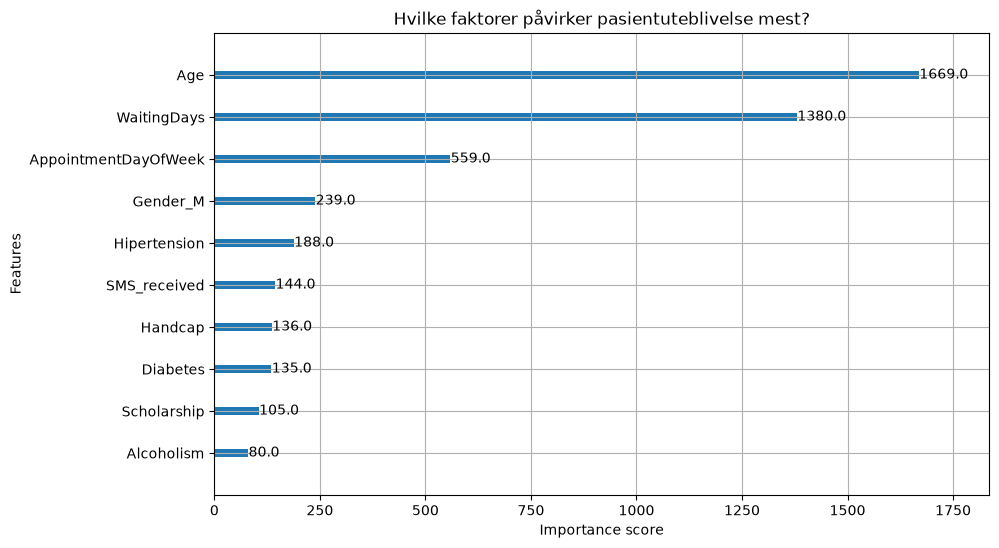

In [11]:
import matplotlib.pyplot as plt

# Juster størrelsen på figuren
plt.figure(figsize=(10, 6))

# Plot de viktigste egenskapene (features) i XGBoost-modellen
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=10, ax=plt.gca())
plt.title('Hvilke faktorer påvirker pasientuteblivelse mest?')
plt.show()